# Deployment 5 — multi-day quicklook (keys `0`, `4`, `04`)

Memory-safe version of the daily quicklook notebooks. The old pattern crashed the
kernel because `io.read_hdf5` loads **all 12 correlation products as
float64/complex128** and `get_dat` re-reads the whole file once *per key* — roughly
10× the memory and 3× the IO actually needed. This notebook instead:

- reads only the keys you ask for, directly with `h5py`, as float32 / complex64;
- averages `TIME_AVG` consecutive integrations (~0.55 s each) at load time;
- prints a **memory estimate before loading** so you can adjust;
- row-bins waterfalls to `DISPLAY_MAX_ROWS` before `imshow`, so figures stay small
  no matter how much data is loaded (with `%matplotlib widget` every open figure
  keeps its plotted array alive).

Rough guide for this 16 GB machine with all three keys:
one day → `TIME_AVG = 1–2`, two–three days → `4`, all ~6 days → `8`.
Loading everything from the T5 takes a couple of minutes.


In [1]:
%matplotlib widget
import glob
from datetime import datetime, timezone
import h5py
import numpy as np
import matplotlib.pyplot as plt


In [2]:
DATA_DIR = "/media/christian/Samsung_T5/eigsep_data/deployment5"

# One glob pattern per chunk of data to load, e.g.
#   ["corr_20260716*.h5"]                        one day
#   ["corr_20260716*.h5", "corr_20260717*.h5"]   two days
#   ["corr_20260718_0[0-2]*.h5"]                 hours 00-02 of Jul 18
# None loads everything.
PATTERNS = None

KEYS = ["0", "4", "04"]  # any subset of these
TIME_AVG = 8             # integrations averaged at load (1 = full ~0.55 s resolution)
NCHAN = 1024

if PATTERNS is None:
    PATTERNS = ["corr_*.h5"]
files = np.array(sorted(set(sum([glob.glob(f"{DATA_DIR}/{p}") for p in PATTERNS], []))))
print(f"{len(files)} files")
dates = np.array([f.split("corr_")[1][:8] for f in files])
for d in np.unique(dates):
    print(f"  {d}: {(dates == d).sum()} files")


5114 files
  20260712: 155 files
  20260713: 1283 files
  20260714: 1255 files
  20260715: 1011 files
  20260716: 670 files
  20260717: 660 files
  20260718: 80 files


In [3]:
def fname_unix(fn):
    """File-close time from the filename. Typically ~5 s after the last
    integration; up to ~16 min late when the writer backlogs."""
    s = fn.split("corr_")[-1][:16]  # YYYYMMDD_HHMMSSZ
    dt = datetime.strptime(s, "%Y%m%d_%H%M%SZ").replace(tzinfo=timezone.utc)
    return dt.timestamp()

def scan(files):
    """Integrations + first acc_cnt per file (0/-1 = unreadable). Metadata-only."""
    n = np.zeros(len(files), dtype=int)
    a0 = np.full(len(files), -1.0)
    for i, fn in enumerate(files):
        try:
            with h5py.File(fn, "r") as f:
                n[i] = f["header/times"].shape[0]
                a0[i] = f["header/acc_cnt"][0]
        except Exception:
            pass
    return n, a0

nrows_in, acc0 = scan(files)
# Backlog flushes write several files in the same second with '-1','-2',...
# name suffixes; plain sorted order puts '-1' (later data) BEFORE the base
# file. Break filename-time ties with acc_cnt to restore true time order.
fname_t = np.array([fname_unix(f) for f in files])
order = np.lexsort((acc0, fname_t))
files, nrows_in, fname_t = files[order], nrows_in[order], fname_t[order]

bad = (nrows_in == 0).sum()
nout_per_file = nrows_in // TIME_AVG
n_rows = int(nout_per_file.sum())

bytes_per_row = sum(8 if len(k) == 2 else 4 for k in KEYS) * NCHAN
est_gb = n_rows * bytes_per_row / 1e9
avail_gb = int(open("/proc/meminfo").read().split("MemAvailable:")[1].split()[0]) / 1e6
print(f"{n_rows} integrations after averaging ({bad} unreadable files)")
print(f"estimated array memory: {est_gb:.1f} GB, available now: {avail_gb:.1f} GB")
if est_gb > 0.5 * avail_gb:
    print("WARNING: >50% of available RAM -- increase TIME_AVG or load fewer days/keys")


153252 integrations after averaging (2 unreadable files)
estimated array memory: 2.5 GB, available now: 10.5 GB


In [4]:
# Time axis uses filename times, good enough for day-boundary labels.
# header/times is the precise per-integration clock (sync_time + acc_cnt
# x integration_time) BUT ~12% of files carry a sync_time captured from
# a wrong clock (off by days: May 19 / Jul 9 epochs) -- repair before
# using it for anything quantitative.
def load(files, keys, nout_per_file, time_avg):
    n_rows = int(nout_per_file.sum())
    data = {
        k: np.full((n_rows, NCHAN), np.nan,
                   dtype=np.complex64 if len(k) == 2 else np.float32)
        for k in keys
    }
    times = np.full(n_rows, np.nan)
    starts = np.concatenate([[0], np.cumsum(nout_per_file)])
    skipped = 0
    for i, fn in enumerate(files):
        nout = nout_per_file[i]
        if nout == 0:
            continue
        keep, r = nout * time_avg, starts[i]
        times[r : r + nout] = fname_unix(fn)
        try:
            with h5py.File(fn, "r") as f:
                for k in keys:
                    arr = f["data"][k][:keep]
                    if len(k) == 2:  # cross stored as (..., 2) = (re, im) int32
                        arr = (arr[..., 0].astype(np.float32)
                               + 1j * arr[..., 1].astype(np.float32))
                    else:
                        arr = arr.astype(np.float32)
                    data[k][r : r + nout] = arr.reshape(nout, time_avg, NCHAN).mean(1)
        except Exception:
            skipped += 1  # rows of this file stay NaN
        if i % 200 == 0:
            print(f"\r{i}/{len(files)}", end="")
    print(f"\r{len(files)}/{len(files)} done, {skipped} files skipped (rows left NaN)")
    return data, times

with h5py.File(files[nrows_in.argmax()], "r") as f:
    freqs = f["header/freqs"][:]
data, times = load(files, KEYS, nout_per_file, TIME_AVG)

t0 = datetime.fromtimestamp(times[0], tz=timezone.utc)
t1 = datetime.fromtimestamp(times[-1], tz=timezone.utc)
print(f"{t0:%Y-%m-%d %H:%M} to {t1:%Y-%m-%d %H:%M} UTC")


5114/5114 done, 0 files skipped (rows left NaN)
2026-07-12 13:31 to 2026-07-18 02:51 UTC


In [5]:
DISPLAY_MAX_ROWS = 4000  # waterfalls are row-binned to at most this before imshow

def rebin_rows(a, max_rows=None):
    """Mean over row blocks so imshow never holds a huge array."""
    max_rows = max_rows or DISPLAY_MAX_ROWS
    fac = int(np.ceil(len(a) / max_rows))
    if fac <= 1:
        return a
    keep = (len(a) // fac) * fac
    return np.nanmean(a[:keep].reshape(-1, fac, a.shape[1]), axis=1)

extent = [freqs.min(), freqs.max(), len(times), 0]
kwargs = {"aspect": "auto", "cmap": "plasma", "extent": extent, "interpolation": "none"}

def day_lines(ax):
    """Dotted line + date label at each UTC day boundary."""
    edges = np.flatnonzero(np.diff(times // 86400)) + 1
    for row in edges:
        ax.axhline(row, color="w", ls=":", lw=0.8)
    for row in np.concatenate([[0], edges]).astype(int):
        lab = datetime.fromtimestamp(times[row], tz=timezone.utc).strftime("%b %d")
        ax.text(0.01, row, " " + lab, color="w", fontsize=8, va="top",
                transform=ax.get_yaxis_transform(),
                bbox={"facecolor": "k", "alpha": 0.4, "pad": 1, "edgecolor": "none"})
    ax.set_xlabel("Frequency [MHz]")
    ax.set_ylabel(f"Integration (x{TIME_AVG} avg)")


/tmp/ipykernel_10250/3428889800.py:3: RuntimeWarning: divide by zero encountered in log10
  plt.imshow(np.log10(rebin_rows(data["0"])), **kwargs, vmin=4, vmax=6.6)
/tmp/ipykernel_10250/3428889800.py:3: RuntimeWarning: invalid value encountered in log10
  plt.imshow(np.log10(rebin_rows(data["0"])), **kwargs, vmin=4, vmax=6.6)


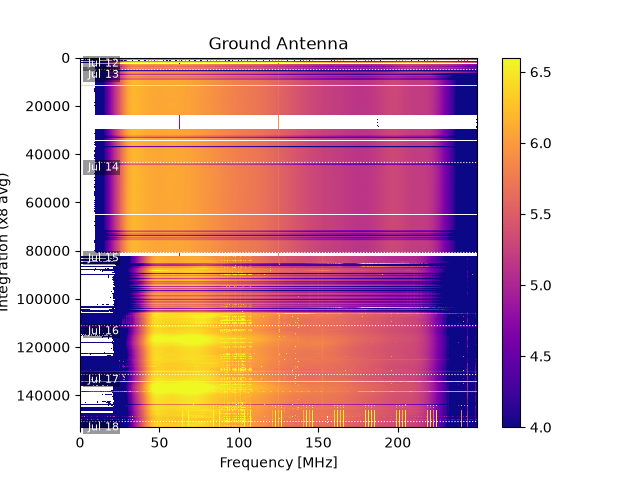

In [6]:
if "0" in data:
    plt.figure()
    plt.imshow(np.log10(rebin_rows(data["0"])), **kwargs, vmin=4, vmax=6.6)
    plt.colorbar()
    day_lines(plt.gca())
    plt.title("Ground Antenna")
    plt.show()


/tmp/ipykernel_10250/3395881488.py:3: RuntimeWarning: divide by zero encountered in log10
  plt.imshow(np.log10(rebin_rows(data["4"])), **kwargs, vmin=4, vmax=6.6)
/tmp/ipykernel_10250/3395881488.py:3: RuntimeWarning: invalid value encountered in log10
  plt.imshow(np.log10(rebin_rows(data["4"])), **kwargs, vmin=4, vmax=6.6)


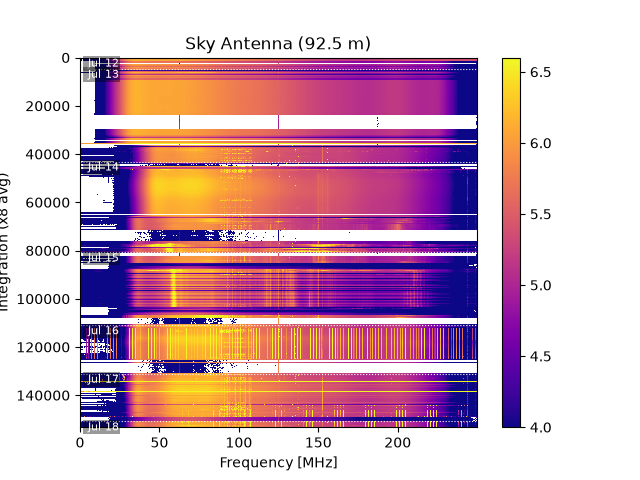

In [7]:
if "4" in data:
    plt.figure()
    plt.imshow(np.log10(rebin_rows(data["4"])), **kwargs, vmin=4, vmax=6.6)
    plt.colorbar()
    day_lines(plt.gca())
    plt.title("Sky Antenna (92.5 m)")
    plt.show()


/tmp/ipykernel_10250/3359074920.py:2: RuntimeWarning: divide by zero encountered in log10
  amp = np.log10(rebin_rows(np.abs(data["04"])))   # incoherent: preserves amplitude


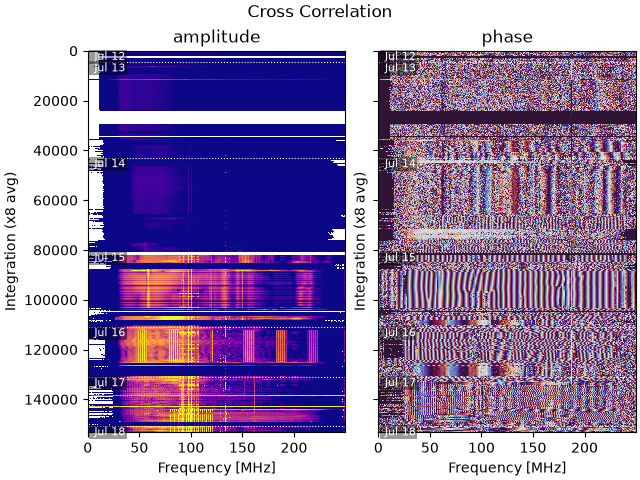

In [8]:
if "04" in data:
    amp = np.log10(rebin_rows(np.abs(data["04"])))   # incoherent: preserves amplitude
    phs = np.angle(rebin_rows(data["04"]))           # coherent: clean fringes
    fig, axs = plt.subplots(ncols=2, sharex=True, sharey=True, constrained_layout=True)
    axs[0].imshow(amp, **kwargs, vmin=3, vmax=6)
    phase_kw = dict(kwargs, cmap="twilight")
    axs[1].imshow(phs, **phase_kw, vmin=-np.pi, vmax=np.pi)
    axs[0].set_title("amplitude")
    axs[1].set_title("phase")
    for ax in axs:
        day_lines(ax)
    fig.suptitle("Cross Correlation")
    plt.show()


In [9]:
plt.close("all")  # uncomment & run when figures pile up -- each open widget figure holds its arrays
